<a href="https://www.kaggle.com/code/omborse771924/fifa-world-cup-2026-squad-lists-eda?scriptVersionId=327996669" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/cabcon/fifa-world-cup-2026-squad-lists-all-48-teams/SquadLists.csv


## Loading Dataset

In [2]:
df = pd.read_csv('/kaggle/input/datasets/cabcon/fifa-world-cup-2026-squad-lists-all-48-teams/SquadLists.csv')

In [3]:
df.head()

,Team,Team Code,Number,Position,Player Name,First Name(s),Last Name(s),Name on Shirt,DOB,Club,Height (cm),Caps,Goals
0,Algeria,ALG,1,GK,MASTIL Melvin,Melvin Feycal,MASTIL,MASTIL,19/02/2000,FC Stade Nyonnais (SUI),194,2,0
1,Algeria,ALG,2,DF,MANDI Aissa,Aissa,MANDI,MANDI,22/10/1991,Lille OSC (FRA),184,119,8
2,Algeria,ALG,3,DF,ABADA Achref,Achref,ABADA,ABADA,15/06/1999,USM Alger (ALG),185,10,1
3,Algeria,ALG,4,DF,TOUGAI Mohamed Amine,Mohamed Amine,TOUGAI,TOUGAI,22/01/2000,Espérance De Tunisie (TUN),186,30,2
4,Algeria,ALG,5,DF,BELAID Zineddine,Zineddine,BELAÏD,BELAID,20/03/1999,JS Kabylie (ALG),186,18,1


In [4]:
df.tail()

,Team,Team Code,Number,Position,Player Name,First Name(s),Last Name(s),Name on Shirt,DOB,Club,Height (cm),Caps,Goals
1243,Uzbekistan,UZB,22,MF,FAYZULLAEV Abbosbek,Abbosbek,FAYZULLAEV,FAYZULLAEV,03/10/2003,Başakşehir FK (TUR),167,32,8
1244,Uzbekistan,UZB,23,MF,ESANOV Sherzod,Sherzod,ESANOV,ESANOV,01/02/2003,FK Buxoro (UZB),190,1,0
1245,Uzbekistan,UZB,24,DF,KARIMOV Behruzjon,Behruzjon,KARIMOV,KARIMOV,07/08/2007,Surkhon FK (UZB),172,2,0
1246,Uzbekistan,UZB,25,DF,ULMASALIYEV Avazbek,Avazbek,ULMASALIYEV,ULMASALIYEV,27/03/2000,OKMK FK (UZB),187,0,0
1247,Uzbekistan,UZB,26,DF,UROZOV Jakhongir,Jakhongir,UROZOV,UROZOV,18/01/2004,FK Dinamo Samarkand (UZB),190,4,1


In [5]:
df.describe()

,Number,Height (cm),Caps,Goals
count,1248.000000,1248.000000,1248.000000,1248.000000
mean,13.500000,182.766026,34.646635,4.490385
std,7.503007,6.828503,32.144187,10.329996
min,1.000000,160.000000,0.000000,0.000000
25%,7.000000,178.000000,11.000000,0.000000
50%,13.500000,183.000000,25.000000,1.000000
75%,20.000000,188.000000,50.000000,4.000000
max,26.000000,205.000000,228.000000,143.000000


In [6]:
df.isnull().sum()

Team             0
Team Code        0
Number           0
Position         0
Player Name      0
First Name(s)    0
Last Name(s)     0
Name on Shirt    0
DOB              0
Club             0
Height (cm)      0
Caps             0
Goals            0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
df.columns

Index(['Team', 'Team Code', 'Number', 'Position', 'Player Name',
       'First Name(s)', 'Last Name(s)', 'Name on Shirt', 'DOB', 'Club',
       'Height (cm)', 'Caps', 'Goals'],
      dtype='object')

## EDA


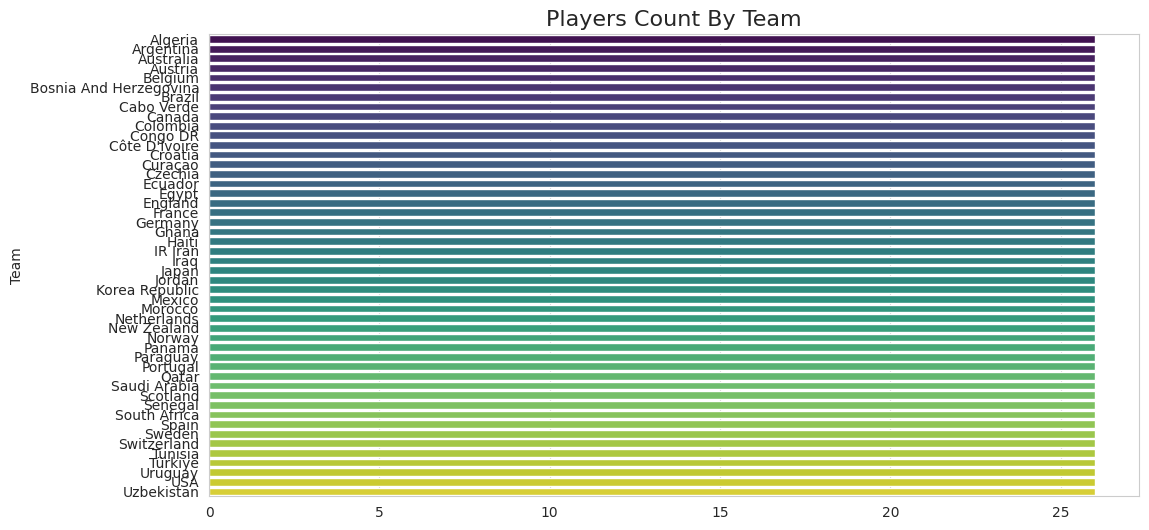

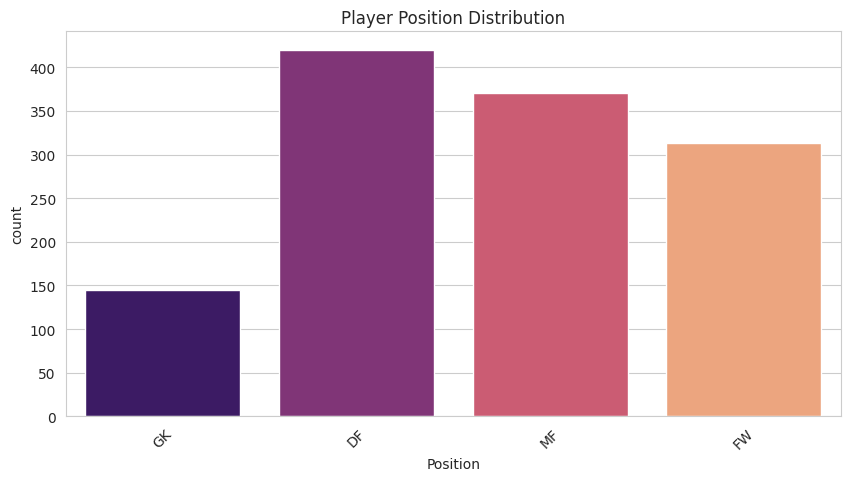

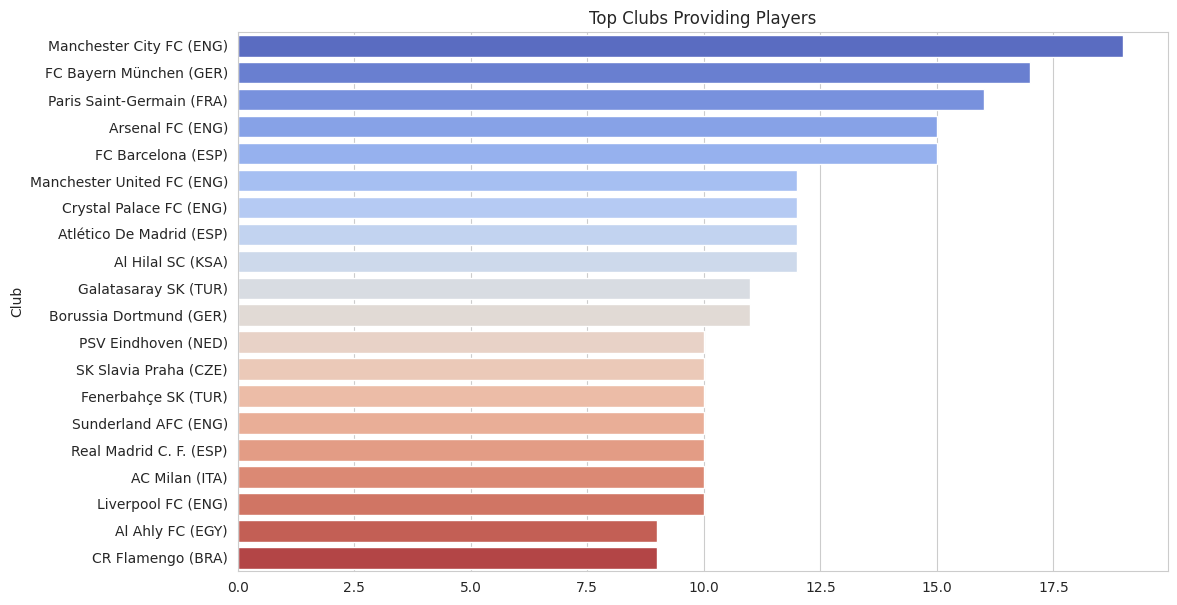

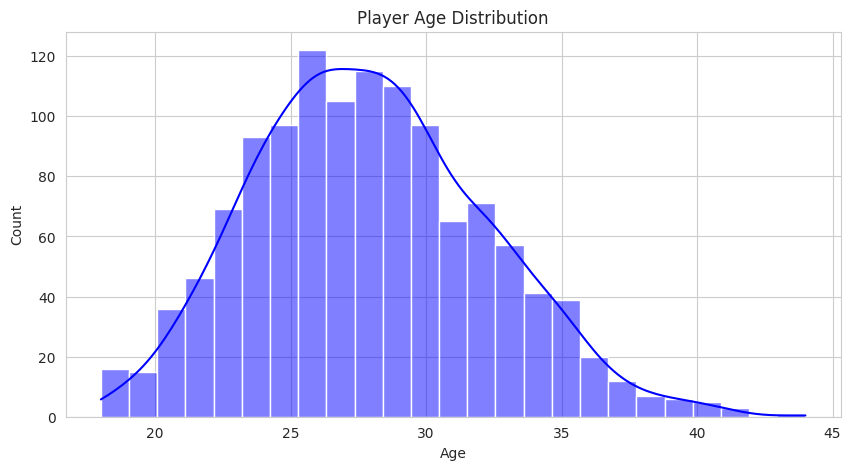

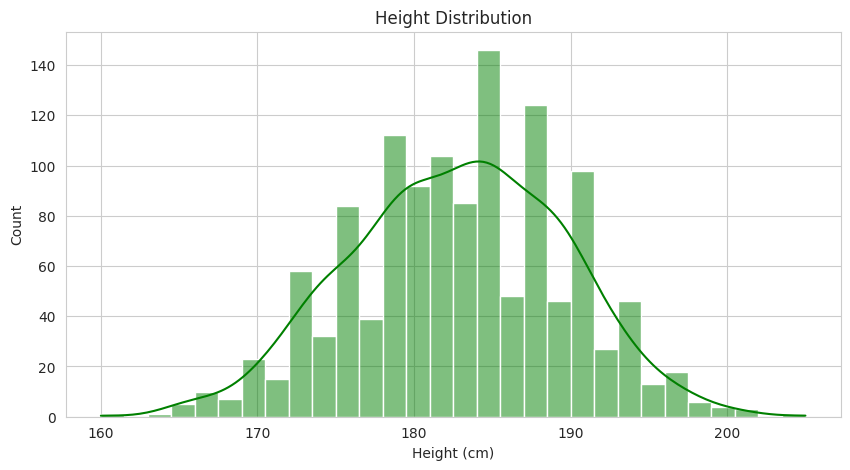

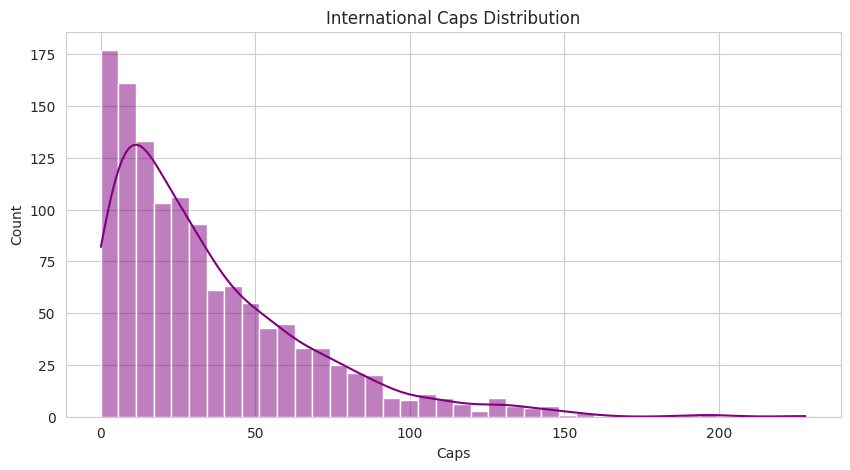

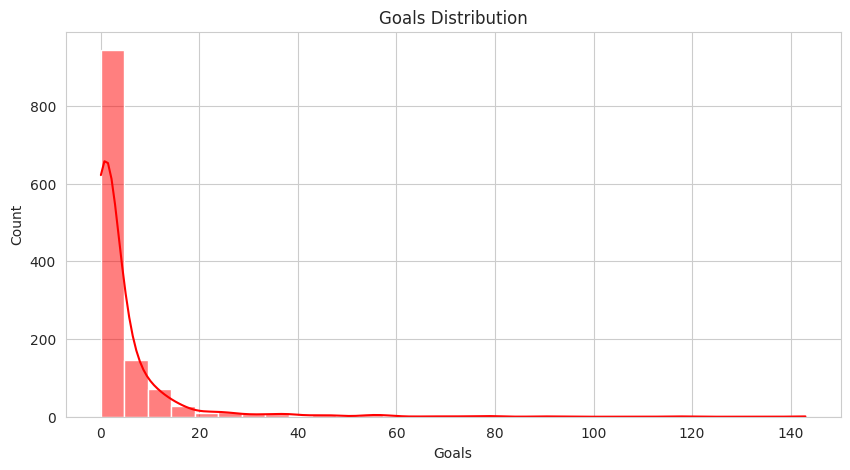

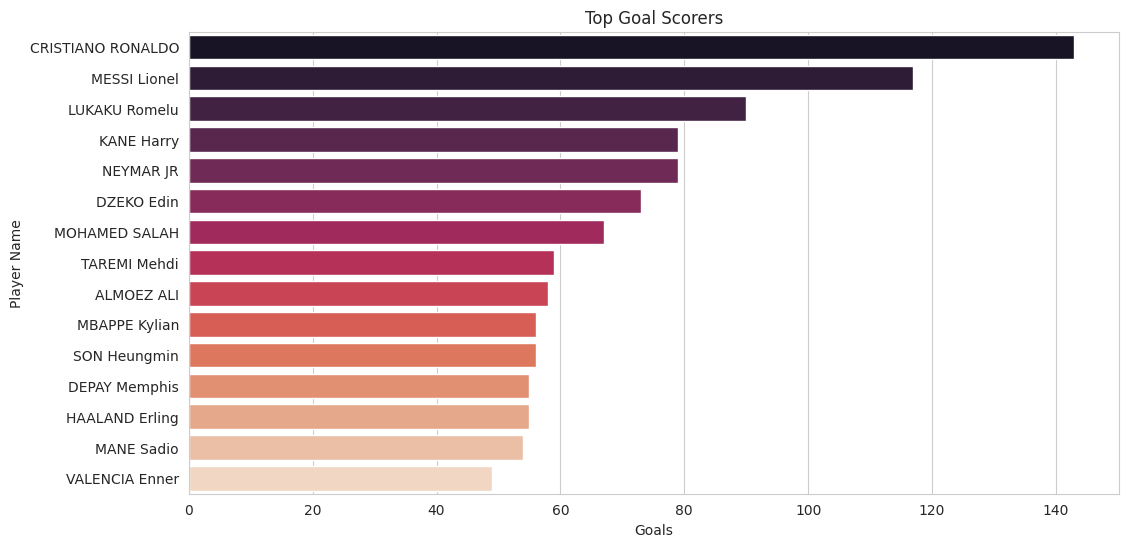

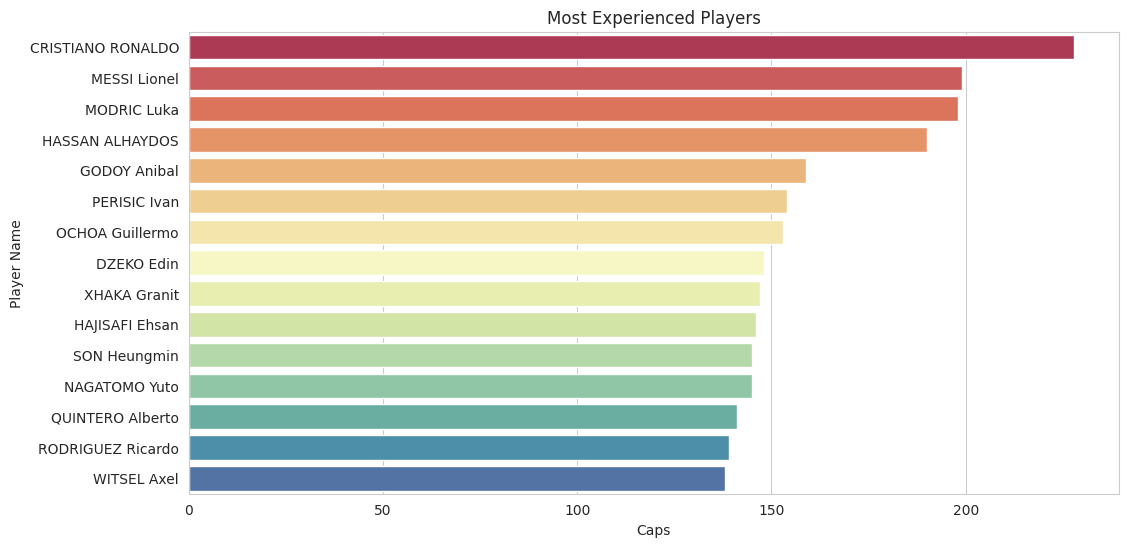

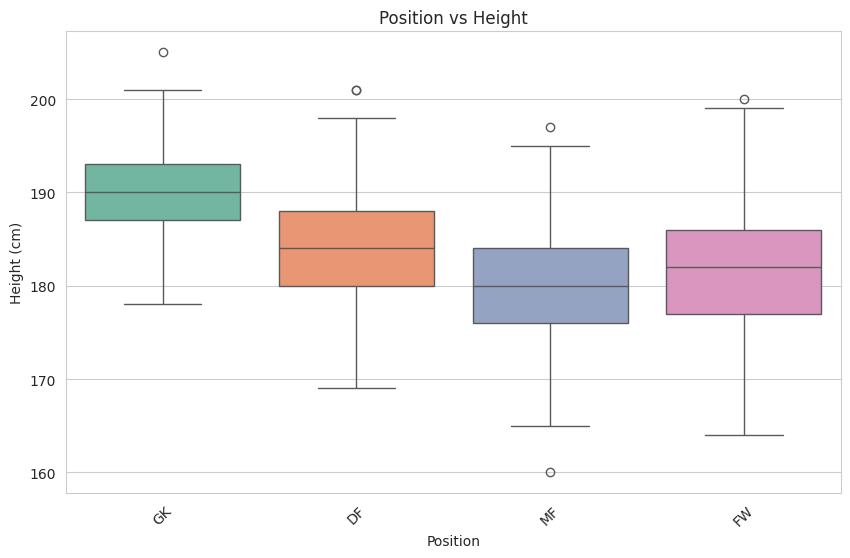

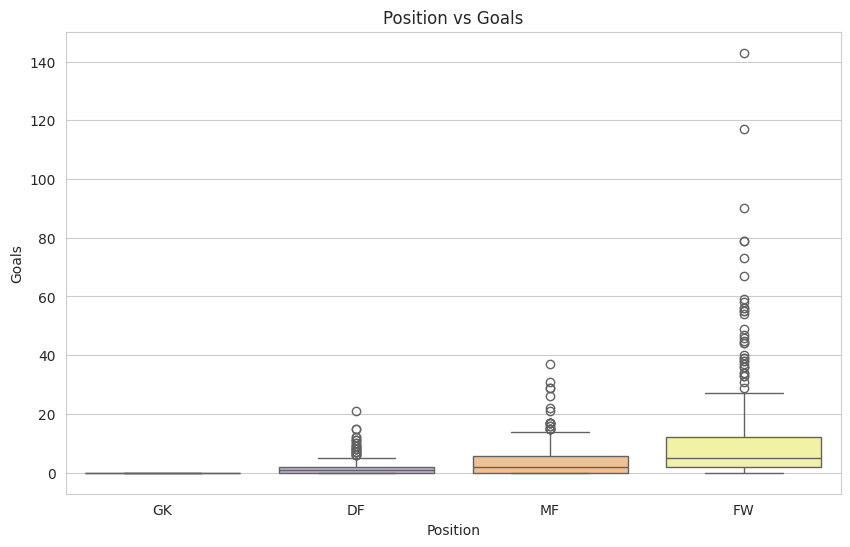

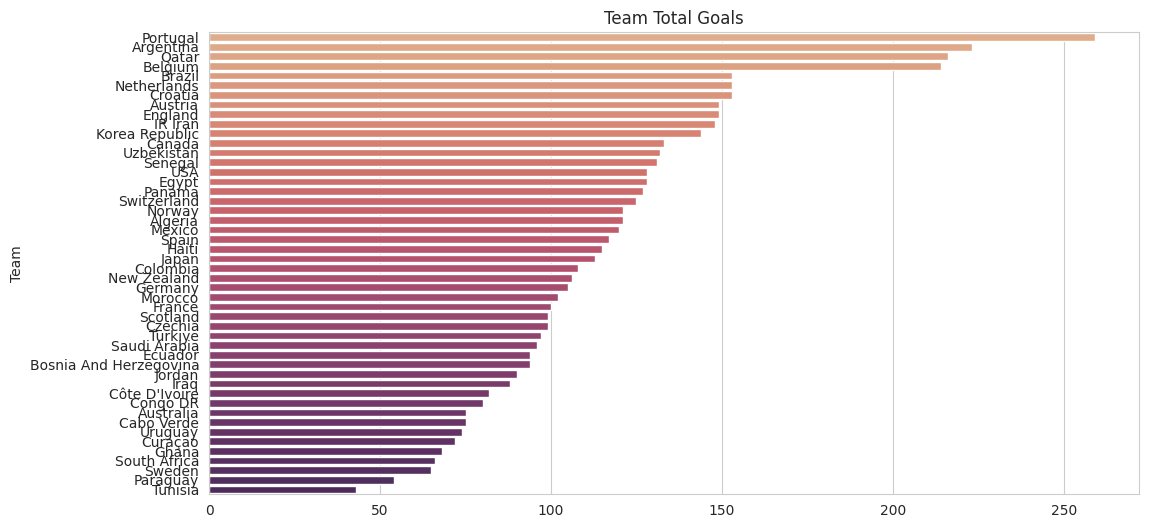

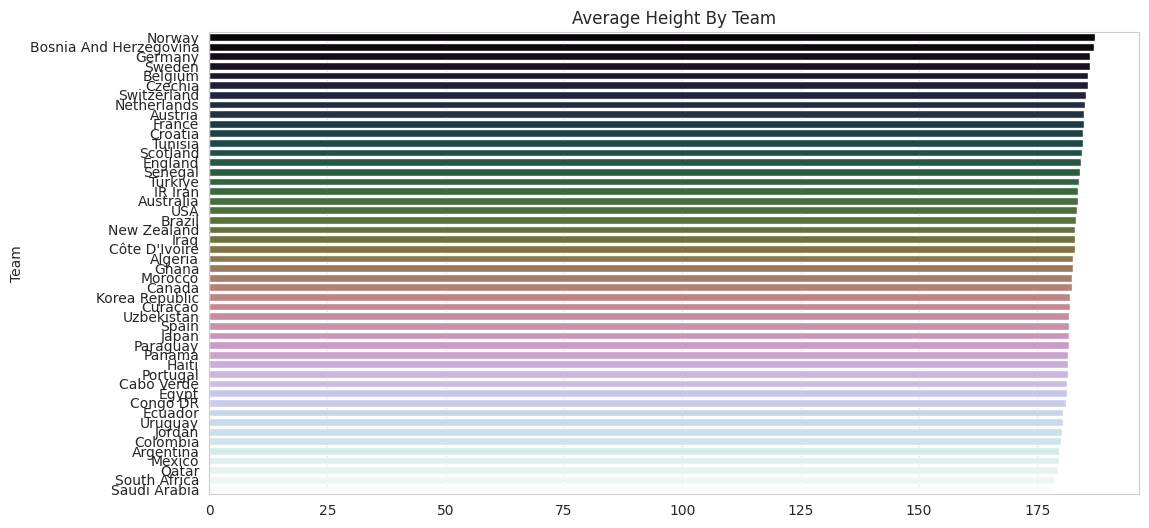

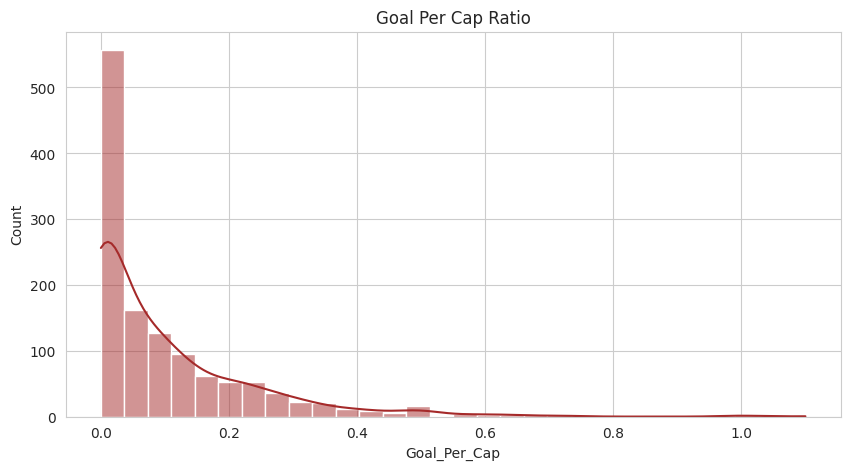

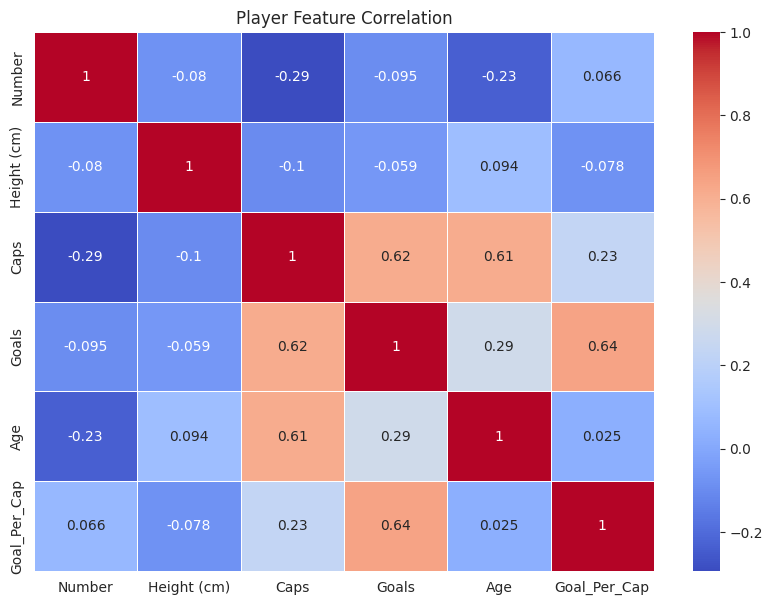

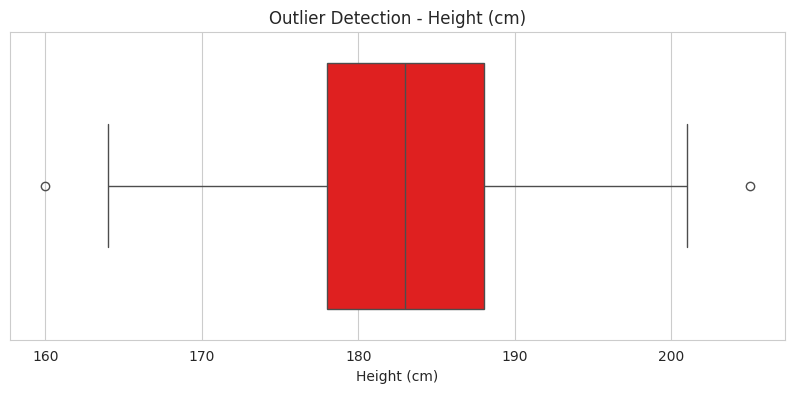

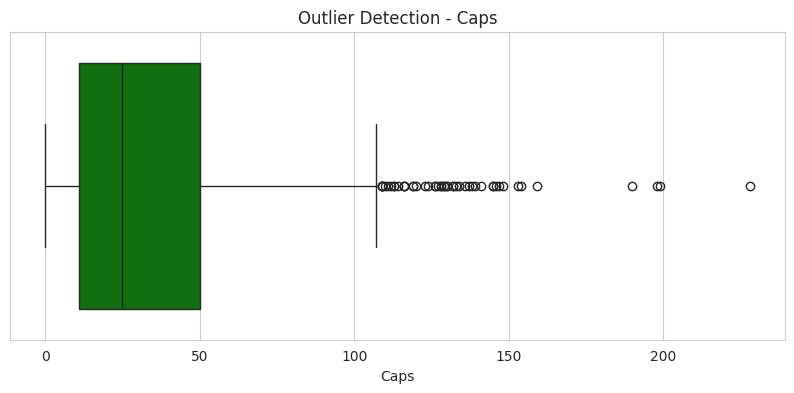

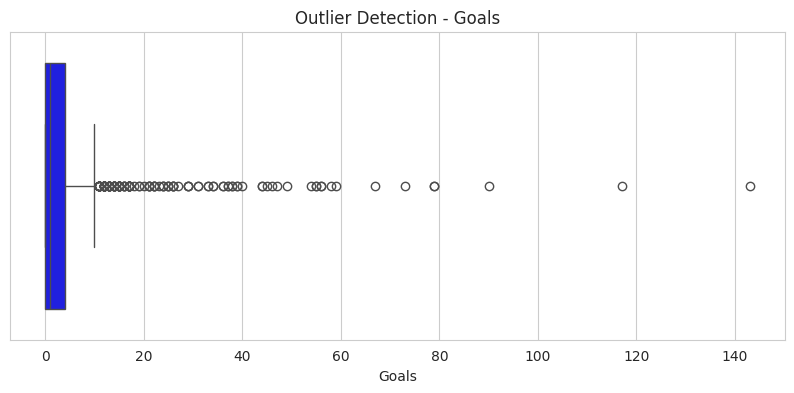

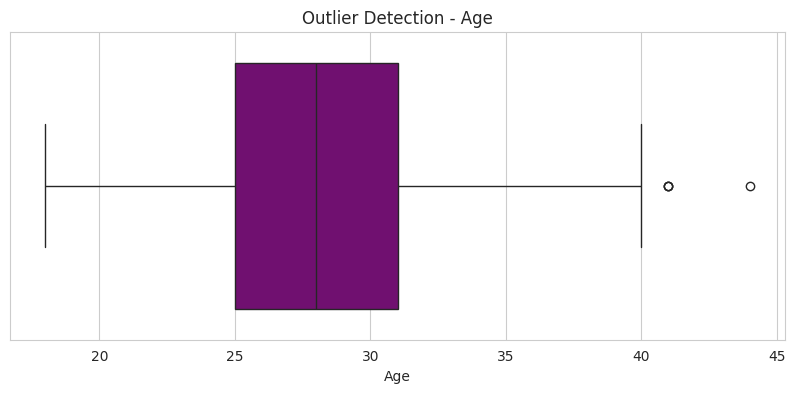

Football Squad Visualization Completed Successfully


In [9]:
sns.set_style("whitegrid")

# ============================================================
# DATE OF BIRTH PROCESSING
# ============================================================

df["DOB"] = pd.to_datetime(
    df["DOB"],
    errors="coerce"
)



df["Age"] = (

    pd.Timestamp.today().year

    -

    df["DOB"].dt.year

)








# ============================================================
# 1. TEAM DISTRIBUTION
# ============================================================


team = df["Team"].value_counts()



plt.figure(figsize=(12,6))


sns.barplot(

    x=team.values,

    y=team.index,

    hue=team.index,

    palette="viridis",

    legend=False

)



plt.title(
    "Players Count By Team",
    fontsize=16
)


plt.show()









# ============================================================
# 2. POSITION DISTRIBUTION
# ============================================================


plt.figure(figsize=(10,5))


sns.countplot(

    data=df,

    x="Position",

    hue="Position",

    palette="magma",

    legend=False

)


plt.title(
    "Player Position Distribution"
)


plt.xticks(rotation=45)


plt.show()







# ============================================================
# 3. CLUB DISTRIBUTION
# ============================================================


clubs = (

df["Club"]
.value_counts()
.head(20)

)




plt.figure(figsize=(12,7))


sns.barplot(

    x=clubs.values,

    y=clubs.index,

    hue=clubs.index,

    palette="coolwarm",

    legend=False

)



plt.title(
    "Top Clubs Providing Players"
)


plt.show()









# ============================================================
# 4. AGE DISTRIBUTION
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

    df["Age"],

    bins=25,

    kde=True,

    color="blue"

)



plt.title(
    "Player Age Distribution"
)


plt.show()








# ============================================================
# 5. HEIGHT DISTRIBUTION
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

    df["Height (cm)"],

    bins=30,

    kde=True,

    color="green"

)



plt.title(
    "Height Distribution"
)


plt.show()







# ============================================================
# 6. CAPS DISTRIBUTION
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

    df["Caps"],

    bins=40,

    kde=True,

    color="purple"

)



plt.title(
    "International Caps Distribution"
)


plt.show()








# ============================================================
# 7. GOALS DISTRIBUTION
# ============================================================


plt.figure(figsize=(10,5))


sns.histplot(

    df["Goals"],

    bins=30,

    kde=True,

    color="red"

)



plt.title(
    "Goals Distribution"
)


plt.show()







# ============================================================
# 8. TOP GOAL SCORERS
# ============================================================


top_goals=(

df.sort_values(
    "Goals",
    ascending=False
)
.head(15)

)



plt.figure(figsize=(12,6))


sns.barplot(

data=top_goals,

x="Goals",

y="Player Name",

hue="Player Name",

palette="rocket",

legend=False

)



plt.title(
"Top Goal Scorers"
)


plt.show()








# ============================================================
# 9. MOST EXPERIENCED PLAYERS
# ============================================================


caps=(

df.sort_values(
"Caps",
ascending=False
)
.head(15)

)



plt.figure(figsize=(12,6))


sns.barplot(

data=caps,

x="Caps",

y="Player Name",

hue="Player Name",

palette="Spectral",

legend=False

)



plt.title(
"Most Experienced Players"
)


plt.show()









# ============================================================
# 10. POSITION VS HEIGHT
# ============================================================


plt.figure(figsize=(10,6))


sns.boxplot(

data=df,

x="Position",

y="Height (cm)",

hue="Position",

palette="Set2",

legend=False

)



plt.title(
"Position vs Height"
)


plt.xticks(rotation=45)


plt.show()









# ============================================================
# 11. POSITION VS GOALS
# ============================================================


plt.figure(figsize=(10,6))


sns.boxplot(

data=df,

x="Position",

y="Goals",

hue="Position",

palette="Accent",

legend=False

)



plt.title(
"Position vs Goals"
)


plt.show()









# ============================================================
# 12. TEAM TOTAL GOALS
# ============================================================


team_goal=(

df.groupby("Team")
["Goals"]
.sum()
.sort_values(
ascending=False
)

)



plt.figure(figsize=(12,6))


sns.barplot(

x=team_goal.values,

y=team_goal.index,

hue=team_goal.index,

palette="flare",

legend=False

)



plt.title(
"Team Total Goals"
)


plt.show()








# ============================================================
# 13. TEAM AVERAGE HEIGHT
# ============================================================


team_height=(

df.groupby("Team")
["Height (cm)"]
.mean()
.sort_values(
ascending=False
)

)



plt.figure(figsize=(12,6))


sns.barplot(

x=team_height.values,

y=team_height.index,

hue=team_height.index,

palette="cubehelix",

legend=False

)


plt.title(
"Average Height By Team"
)


plt.show()







# ============================================================
# 14. GOAL RATIO
# ============================================================


df["Goal_Per_Cap"] = (

df["Goals"]

/

df["Caps"].replace(0,1)

)





plt.figure(figsize=(10,5))


sns.histplot(

df["Goal_Per_Cap"],

bins=30,

kde=True,

color="brown"

)



plt.title(
"Goal Per Cap Ratio"
)


plt.show()







# ============================================================
# 15. CORRELATION HEATMAP
# ============================================================


numeric=df.select_dtypes(
include=np.number
)



plt.figure(figsize=(10,7))


sns.heatmap(

numeric.corr(),

annot=True,

cmap="coolwarm",

linewidth=0.5

)



plt.title(
"Player Feature Correlation"
)


plt.show()








# ============================================================
# 16. OUTLIER DETECTION
# ============================================================


features=[

"Height (cm)",

"Caps",

"Goals",

"Age"

]


colors=[

"red",

"green",

"blue",

"purple"

]





for feature,color in zip(features,colors):


    plt.figure(figsize=(10,4))


    sns.boxplot(

        x=df[feature],

        color=color

    )



    plt.title(
        f"Outlier Detection - {feature}"
    )



    plt.show()






print(
    "Football Squad Visualization Completed Successfully"
)

## Features Engineering


Logistic Regression
Accuracy: 0.532
              precision    recall  f1-score   support

          DF       0.51      0.56      0.53        84
          FW       0.63      0.65      0.64        63
          GK       0.62      0.55      0.58        29
          MF       0.44      0.39      0.41        74

    accuracy                           0.53       250
   macro avg       0.55      0.54      0.54       250
weighted avg       0.53      0.53      0.53       250


Decision Tree
Accuracy: 0.596
              precision    recall  f1-score   support

          DF       0.63      0.68      0.65        84
          FW       0.59      0.59      0.59        63
          GK       0.82      0.62      0.71        29
          MF       0.50      0.50      0.50        74

    accuracy                           0.60       250
   macro avg       0.63      0.60      0.61       250
weighted avg       0.60      0.60      0.60       250


Random Forest
Accuracy: 0.56
              precision    recal

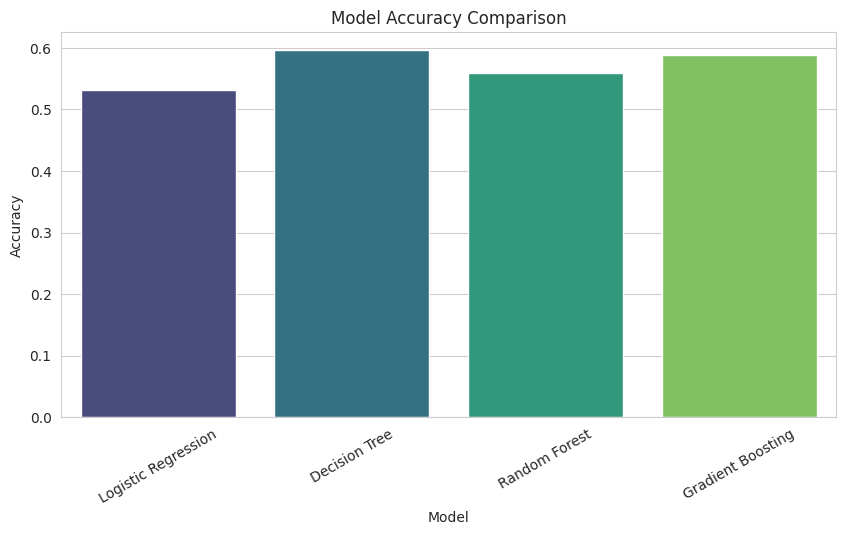

BEST MODEL: Decision Tree


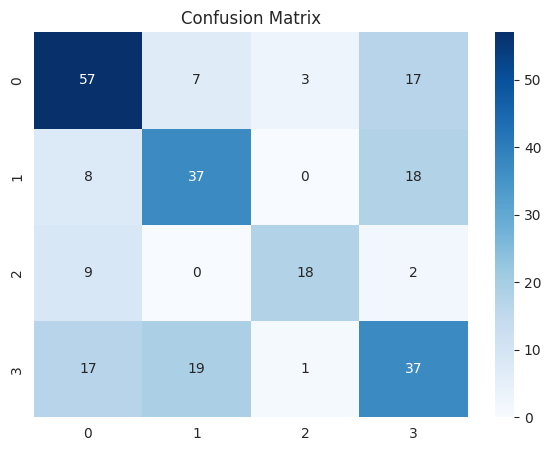

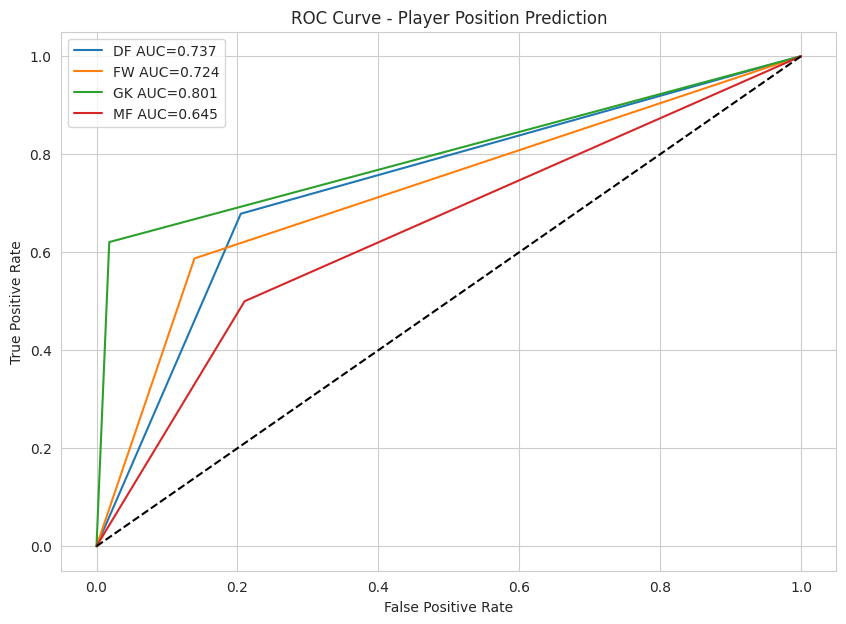

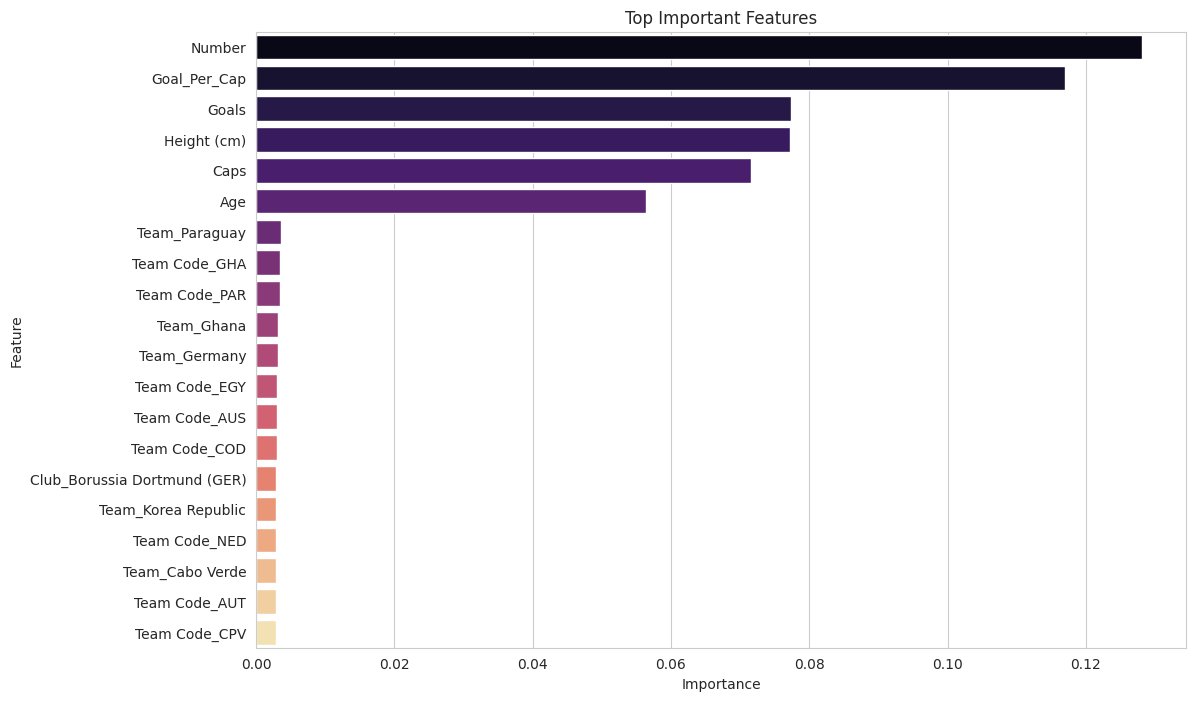


FINAL RESULTS
Logistic Regression : 0.532
Decision Tree : 0.596
Random Forest : 0.56
Gradient Boosting : 0.588
BEST MODEL: Decision Tree
BEST ACCURACY: 0.596


In [10]:
from sklearn.model_selection import train_test_split


from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    label_binarize
)


from sklearn.compose import ColumnTransformer


from sklearn.pipeline import Pipeline


from sklearn.impute import SimpleImputer



from sklearn.linear_model import LogisticRegression


from sklearn.tree import DecisionTreeClassifier


from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier
)


from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score
)
# ============================================================
# DATE FEATURE ENGINEERING
# ============================================================

df["DOB"]=pd.to_datetime(
    df["DOB"],
    errors="coerce"
)


df["Age"] = (

    pd.Timestamp.today().year

    -

    df["DOB"].dt.year

)









# ============================================================
# TARGET
# ============================================================

target="Position"



X=df.drop(
    target,
    axis=1
)



y=df[target]










# ============================================================
# REMOVE DATA LEAKAGE
# ============================================================

drop_cols=[


"Player Name",

"First Name(s)",

"Last Name(s)",

"Name on Shirt",

"DOB"


]



X=X.drop(

columns=drop_cols,

errors="ignore"

)










# ============================================================
# TRAIN TEST SPLIT BEFORE ENCODING
# ============================================================


X_train,X_test,y_train,y_test=train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42,

    stratify=y

)









# ============================================================
# COLUMN TYPES
# ============================================================


numeric_cols=X.select_dtypes(
    include=np.number
).columns



categorical_cols=X.select_dtypes(
    include="object"
).columns









# ============================================================
# NUMERIC PIPELINE
# ============================================================


numeric_pipeline=Pipeline(

steps=[



(

"imputer",

SimpleImputer(
strategy="median"
)

),



(

"scaler",

StandardScaler()

)


]

)









# ============================================================
# CATEGORICAL PIPELINE
# ============================================================


categorical_pipeline=Pipeline(

steps=[


(

"imputer",

SimpleImputer(
strategy="most_frequent"
)

),



(

"encoder",

OneHotEncoder(
handle_unknown="ignore"
)

)


]

)










# ============================================================
# PREPROCESSOR
# ============================================================


preprocessor=ColumnTransformer(

transformers=[


(

"num",

numeric_pipeline,

numeric_cols

),



(

"cat",

categorical_pipeline,

categorical_cols

)


]

)









# ============================================================
# MODELS
# ============================================================


models={



"Logistic Regression":

LogisticRegression(
max_iter=1000
),




"Decision Tree":

DecisionTreeClassifier(
random_state=42
),





"Random Forest":

RandomForestClassifier(

n_estimators=200,

random_state=42

),





"Gradient Boosting":

GradientBoostingClassifier(
random_state=42
)


}










results={}

trained={}









# ============================================================
# TRAIN MODELS
# ============================================================


for name,model in models.items():


    print("\n===================")

    print(name)

    print("===================")




    pipe=Pipeline(

    steps=[



    (
    "preprocess",
    preprocessor
    ),



    (
    "model",
    model
    )



    ]

    )





    pipe.fit(

        X_train,

        y_train

    )







    pred=pipe.predict(

        X_test

    )






    acc=accuracy_score(

        y_test,

        pred

    )






    results[name]=acc

    trained[name]=pipe







    print(

        "Accuracy:",

        round(acc,4)

    )





    print(

        classification_report(

            y_test,

            pred

        )

    )









# ============================================================
# ACCURACY COMPARISON
# ============================================================


accuracy_df=pd.DataFrame({

"Model":list(results.keys()),

"Accuracy":list(results.values())

})





plt.figure(figsize=(10,5))


sns.barplot(

data=accuracy_df,

x="Model",

y="Accuracy",

hue="Model",

palette="viridis",

legend=False

)



plt.title(
"Model Accuracy Comparison"
)



plt.xticks(rotation=30)


plt.show()










# ============================================================
# BEST MODEL
# ============================================================


best_name=max(

results,

key=results.get

)



best_model=trained[

best_name

]




print(

"BEST MODEL:",

best_name

)










# ============================================================
# CONFUSION MATRIX
# ============================================================


best_pred=best_model.predict(

X_test

)





plt.figure(figsize=(7,5))


sns.heatmap(

confusion_matrix(

y_test,

best_pred

),

annot=True,

fmt="d",

cmap="Blues"

)


plt.title(

"Confusion Matrix"

)


plt.show()










# ============================================================
# MULTICLASS ROC CURVE
# ============================================================


classes=np.unique(y)



y_test_bin=label_binarize(

y_test,

classes=classes

)




prob=best_model.predict_proba(

X_test

)






plt.figure(figsize=(10,7))





for i in range(len(classes)):



    fpr,tpr,_=roc_curve(

        y_test_bin[:,i],

        prob[:,i]

    )




    auc=roc_auc_score(

        y_test_bin[:,i],

        prob[:,i]

    )





    plt.plot(

        fpr,

        tpr,

        label=f"{classes[i]} AUC={auc:.3f}"

    )






plt.plot(

[0,1],

[0,1],

"k--"

)



plt.title(
"ROC Curve - Player Position Prediction"
)



plt.xlabel(
"False Positive Rate"
)



plt.ylabel(
"True Positive Rate"
)



plt.legend()


plt.show()









# ============================================================
# FEATURE IMPORTANCE
# ============================================================


rf=trained[

"Random Forest"

]





feature_names=(

list(numeric_cols)

+

list(

rf.named_steps["preprocess"]

.named_transformers_["cat"]

.named_steps["encoder"]

.get_feature_names_out(

categorical_cols

)

)

)






importance=pd.DataFrame({

"Feature":feature_names,


"Importance":

rf.named_steps["model"]

.feature_importances_

})






importance=importance.sort_values(

"Importance",

ascending=False

)





plt.figure(figsize=(12,8))


sns.barplot(

data=importance.head(20),

x="Importance",

y="Feature",

hue="Feature",

palette="magma",

legend=False

)



plt.title(
"Top Important Features"
)


plt.show()








# ============================================================
# FINAL RESULT
# ============================================================


print("\nFINAL RESULTS")
print("================")


for model,score in results.items():

    print(

        model,

        ":",

        round(score,4)

    )



print("================")


print(

"BEST MODEL:",

best_name

)



print(

"BEST ACCURACY:",

round(max(results.values()),4)

)

## Thanks.................Please Upvote